# Test 8— CNN input fix and pseudo-labelling of the Kaggle test

**Starting point (Test 6b).** The best submission so far is the blend of `CNN6b_3_aug` and B0 (CNN weight 0.25): private 0.703, public 0.689. The CNN on its own scores about 0.71 private but only 0.55–0.59 public. Test 6b's diagnosis found two things to act on:
1. The CNN's extra false alarms on the Kaggle test come from **quiet recordings** (lowest noise floor). A low noise floor lets more small peaks through and inflates every peak's height relative to it, so these recordings look active to the CNN.
2. Training and Kaggle-test recordings are **clearly different** (adversarial AUC 0.914).

**Two changes, judged separately:**

| Step | Change | Targets |
|---|---|---|
| **7a — CNN input fix** | `CNN6b_3_aug` with (i) a **floor on the noise floor**: in traces quieter than the typical training trace, peaks below the typical noise floor are dropped and heights are taken relative to the typical noise floor; (ii) **inputs clipped to the range seen in training**, so an unusual input can't push the CNN beyond anything it learned (the way a tree model behaves) | Finding 1 |
| **7b — Pseudo-labelling** | Kaggle-test measurements on which the Test 6b blend is very confident are added to the training data with its predicted label (weight 0.5). Both B0 and the 7a CNN are retrained with them, then blended | Finding 2 |

**How pseudo-labels are chosen.** Confidence thresholds are set on the Test 6b blend's **CV predictions**, where the true labels are known: the PD threshold is the lowest at which at least **95%** of pool measurements above it are PD; the normal threshold is the highest at which at most **0.5%** below it are PD. Pseudo-labelled normals are sampled so that the PD share matches the pool's. Pseudo-labels are added **only to the training part** of each fold, never to the scoring or stopping fold, so CV is still scored on real labels only.

**What CV can and can't show.** CV measures performance on recordings like the training data. Pseudo-labelling targets the hidden test, so its effect can only be judged on the leaderboard. Its CV score may also be slightly optimistic, because the teacher was trained on all pool folds.

**Pre-registered submissions (fixed before any result is seen):** (1) `Blend_7a` (CNN7a + B0); (2) `Blend_7b` (CNN7b + B0_PL). If a blend's chosen weight is w = 1, its CNN is submitted instead; if w = 0, `Blend_7a` is not submitted (it would be B0) and `Blend_7b` is replaced by B0_PL. Both private and public scores are reported and judged together.

**Inputs to attach:** the committed outputs of **Data prep v4**, **Test 5** and **Test 6b**. Switch on the GPU. Run once with `QUICK_TEST = True`, then set it to `False` and commit with **Save & Run All**.

## 1. Settings

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import glob, json, random, time, warnings
warnings.filterwarnings('ignore', message='.*eval_set.*')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import matthews_corrcoef, confusion_matrix

torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

QUICK_TEST = False          # True = few repeats and 5 epochs, only to check the notebook runs

N_REPEATS, N_FOLDS, SEED_BASE = (1 if QUICK_TEST else 10), 5, 1000   # CNN: same folds as Tests 5, 6 and 6b
N_REPEATS_B0 = 2 if QUICK_TEST else 25                              # B0: as in Test 5
N_BINS = 64
BATCH_SIZE, MAX_EPOCHS, PATIENCE, LR, WEIGHT_DECAY = 64, (5 if QUICK_TEST else 150), 20, 1e-3, 1e-3
MAX_SHIFT, PHASE_SHIFT, HEIGHT_JITTER, BIN_DROP = 2, 1, 0.25, 0.05  # 6b-3 augmentation, unchanged
PL_PRECISION = 0.95         # pseudo-PD: at least 95% of CV measurements above the threshold are PD
PL_NEG_PD_SHARE = 0.005     # pseudo-normal: at most 0.5% of CV measurements below the threshold are PD
PL_MIN_POS = 20             # the PD threshold must cover at least 20 CV measurements
PL_WEIGHT = 0.5             # weight of a pseudo-labelled measurement in training (real ones: 1)
LGB_PARAMS = dict(objective='binary', learning_rate=0.01, num_leaves=80, colsample_bytree=0.8,
                  subsample=0.8, subsample_freq=1, n_estimators=10000, verbose=-1)   # winner's settings (Test 5)
EARLY_STOP = 100
THRESHOLDS = np.r_[np.arange(0.01, 0.99, 0.01), np.arange(0.99, 0.9995, 0.001)].round(3)
INPUT_DIR, OUT_DIR = '/kaggle/input', '/kaggle/working'
C_B0, C_CNN, C_AQUA, C_GRAY = '#2a78d6', '#eb6834', '#1baf7a', '#8a8985'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device, '| PyTorch', torch.__version__, '| LightGBM', lgb.__version__, '| QUICK_TEST' if QUICK_TEST else '')
T_START = time.time()

Using device: cuda | PyTorch 2.11.0+cu128 | LightGBM 4.6.0 


## 2. Load the inputs

Data prep v4 gives the peak tables and per-signal statistics. Test 5 gives B0's saved predictions and Test 6b gives `CNN6b_3_aug`'s; together they rebuild the Test 6b blend, which is the **teacher** for the pseudo-labels.

In [2]:
def find(name, required=True):
    m = sorted(glob.glob(f'{INPUT_DIR}/**/{name}', recursive=True))
    assert m or not required, f'{name} not found: attach the committed output that contains it'
    return m[0] if m else None

D = find('peaks_train.parquet').rsplit('/', 1)[0]
meta = pd.read_csv(f'{D}/meta_train.csv')
meta_k = pd.read_csv(f'{D}/meta_kaggle_test.csv')
assert len(meta) == 8712 and len(meta_k) == 20337, 'quick-test output attached: commit Data prep v4 with LIMIT = None'

t5 = np.load(find('test5_predictions.npz'))
t6b = np.load(find('test6b_predictions.npz'))
set6b = json.load(open(find('test6b_settings.json')))
TEACHER_CNN, TEACHER_W = set6b['best_variant'], set6b['blend_weight']
assert 0 < TEACHER_W < 1, 'the Test 6b blend weight should be between 0 and 1'
print(f'Teacher: Test 6b blend of {TEACHER_CNN} and B0 with CNN weight w = {TEACHER_W}')

Teacher: Test 6b blend of CNN6b_3_aug and B0 with CNN weight w = 0.25


## 3. Peak tables, the noise-floor floor, grids and B0 features

**The floor.** `KNEE_FLOOR` is the median noise-floor height (knee) of the pool signals. For each trace, the effective noise floor becomes max(own knee, `KNEE_FLOOR`): peaks below it are dropped, and relative heights are divided by it. Traces at or above the typical noise floor are unchanged, so this only affects quiet recordings.

The grids are otherwise built exactly as in Tests 6 and 6b. B0's 9 features (for B0 and for the CNN's side input) use the original peaks, without the floor.

In [3]:
COUNT_CH = ['count', 'count_pos', 'count_neg', 'sum_rel_height']
MEAN_CH = ['sawtooth_2', 'sawtooth_3', 'ratio_next', 'ratio_prev', 'abs_dist', 'width']
CHANNELS = COUNT_CH + MEAN_CH
N_CH = len(CHANNELS)

def load(name, m):
    p = pd.read_parquet(f'{D}/peaks_{name}.parquet')
    s = pd.read_csv(f'{D}/signals_{name}.csv').merge(m[['signal_id', 'id_measurement', 'phase']], on='signal_id')
    p = p.merge(m[['signal_id', 'id_measurement', 'phase']], on='signal_id').merge(s[['signal_id', 'knee_height']], on='signal_id')
    p = p[~((p['ratio_next'] > 1 / 3) & (p['height'] > 50))].copy()             # winner's interference filter
    p['abs_dist'] = p['small_dist_to_min'].abs().astype(np.float32)
    p['bin'] = (p['phase_deg'] / (360 / N_BINS)).astype(int).clip(0, N_BINS - 1)
    return p, s

peaks, sig = load('train', meta)
peaks_k, sig_k = load('kaggle_test', meta_k)

ids_all = np.sort(meta['id_measurement'].unique()); ids_k = np.sort(meta_k['id_measurement'].unique())
y_meas = meta.groupby('id_measurement')['target'].max().loc[ids_all].values
split = meta.groupby('id_measurement')['split'].first().loc[ids_all].values
pool = np.where(np.isin(split, ['train', 'val']))[0]
test_rows = np.where(split == 'test')[0]
pool_ids, yp = ids_all[pool], y_meas[pool]
pool_sig = meta[meta['id_measurement'].isin(pool_ids)]

KNEE_FLOOR = float(sig.loc[sig['id_measurement'].isin(pool_ids), 'knee_height'].median())

def apply_floor(p):
    floor = np.maximum(p['knee_height'].values, KNEE_FLOOR)
    p = p[p['height'].values >= floor].copy()
    p['rel_height'] = p['height'] / np.maximum(p['knee_height'], KNEE_FLOOR)
    return p

pf, pf_k = apply_floor(peaks), apply_floor(peaks_k)
FILL = pf[MEAN_CH].astype(float).mean()

def build_grid(p, ids):                                  # as in Tests 6 and 6b
    row = pd.Series(np.arange(len(ids)), index=ids)
    r, ph, b = row.loc[p['id_measurement']].values, p['phase'].values, p['bin'].values
    G = np.zeros((len(ids), 3, N_CH, N_BINS), dtype=np.float32)
    np.add.at(G, (r, ph, 0, b), np.ones(len(p), dtype=np.float32))
    np.add.at(G, (r, ph, 1, b), (p['sign'].values > 0).astype(np.float32))
    np.add.at(G, (r, ph, 2, b), (p['sign'].values < 0).astype(np.float32))
    np.add.at(G, (r, ph, 3, b), p['rel_height'].values.astype(np.float32))
    counts = G[:, :, 0, :].copy()
    for j, c in enumerate(MEAN_CH, start=len(COUNT_CH)):
        np.add.at(G, (r, ph, j, b), p[c].values.astype(np.float32))
        G[:, :, j, :] = np.where(counts > 0, G[:, :, j, :] / np.maximum(counts, 1), FILL[c])
    G[:, :, :len(COUNT_CH), :] = np.log1p(G[:, :, :len(COUNT_CH), :])
    return G.reshape(len(ids), 3 * N_CH, N_BINS)

G, G_k = build_grid(pf, ids_all), build_grid(pf_k, ids_k)

B0_COLS = ['peak_count_Q13', 'abs_small_dist_to_min_mean_Q02', 'height_mean_Q02', 'height_std_Q02',
           'sawtooth_rmse_mean_Q02', 'peak_count_Q02', 'ratio_next_mean_Q02', 'ratio_prev_mean_Q02', 'peak_count_total']

def b0_features(p, ids):                                 # B0 part of Test 5's build_features (peaks already filtered)
    p = p.assign(Q=(p['phase_deg'] // 90).astype(int).clip(0, 3))
    f = pd.DataFrame(index=pd.Index(ids, name='id_measurement'))
    g = p[p['Q'].isin([0, 2])].groupby('id_measurement')
    f['peak_count_Q02'] = g.size()
    f['peak_count_Q13'] = p[p['Q'].isin([1, 3])].groupby('id_measurement').size()
    f['peak_count_total'] = p.groupby('id_measurement').size()
    f['height_mean_Q02'] = g['height'].mean()
    f['height_std_Q02'] = g['height'].std()
    f['ratio_prev_mean_Q02'] = g['ratio_prev'].mean()
    f['ratio_next_mean_Q02'] = g['ratio_next'].mean()
    f['abs_small_dist_to_min_mean_Q02'] = g['abs_dist'].mean()
    f['sawtooth_rmse_mean_Q02'] = g['sawtooth_3'].mean()
    return f[B0_COLS]

F_b0, F_b0_k = b0_features(peaks, ids_all), b0_features(peaks_k, ids_k)
SIDE, SIDE_K = F_b0.copy(), F_b0_k.copy()                # side input for the CNN, as in Test 6b
for S, F in ((SIDE, F_b0), (SIDE_K, F_b0_k)):
    for c in ['peak_count_Q02', 'peak_count_Q13', 'peak_count_total']:
        S[c] = np.log1p(F[c].fillna(0))
    for c in ['height_mean_Q02', 'height_std_Q02']:
        S[c] = np.log1p(F[c])
    S['no_Q02_peaks'] = (F['peak_count_Q02'].fillna(0) == 0).astype(float)
SIDE, SIDE_K = SIDE.values.astype(np.float64), SIDE_K.values.astype(np.float64)
N_SIDE = SIDE.shape[1]

quiet = sig.groupby('id_measurement')['knee_height'].mean().loc[ids_all].values < KNEE_FLOOR
quiet_k = sig_k.groupby('id_measurement')['knee_height'].mean().loc[ids_k].values < KNEE_FLOOR
print(f'Noise-floor floor (median pool knee height): {KNEE_FLOOR:.2f}')
print(f'Peaks removed by the floor: {1 - len(pf) / len(peaks):.1%} labelled, {1 - len(pf_k) / len(peaks_k):.1%} Kaggle test')
print(f'Quiet measurements (mean knee below the floor): {quiet[pool].mean():.1%} of pool, {quiet_k.mean():.1%} of Kaggle test')
print('Grid:', G.shape, '| Kaggle:', G_k.shape, f'| pool: {len(pool)} measurements ({yp.sum()} PD), {len(pool_sig)} signals')

Noise-floor floor (median pool knee height): 5.37
Peaks removed by the floor: 11.7% labelled, 11.0% Kaggle test
Quiet measurements (mean knee below the floor): 50.8% of pool, 46.0% of Kaggle test
Grid: (2904, 30, 64) | Kaggle: (6779, 30, 64) | pool: 2468 measurements (165 PD), 7404 signals


## 4. Scoring functions and the teacher

Same scoring as Test 6b (signal level, cut-off from CV predictions, ties to the middle). The teacher is rebuilt from the saved predictions with the same calibration and weight as in Test 6b; its CV score should reproduce Test 6b's (0.729), and B0's and the CNN's should reproduce 0.726 and 0.704.

In [4]:
def to_signal(p, ids, m):
    return m['id_measurement'].map(pd.Series(p, index=ids)).values

def best_signal_cut(p):
    ps, ys = to_signal(p, pool_ids, pool_sig), pool_sig['target'].values
    scores = np.array([matthews_corrcoef(ys, ps > t) for t in THRESHOLDS])
    tied = np.flatnonzero(scores == scores.max())
    i = int(tied[len(tied) // 2]); return float(scores[i]), float(THRESHOLDS[i])

def meas_mcc(p):
    return max(matthews_corrcoef(yp, p > t) for t in THRESHOLDS)

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p))

def calibrator(p, y):
    lr = LogisticRegression(C=1e6).fit(logit(p)[:, None], y)
    return lambda q: lr.predict_proba(logit(q)[:, None])[:, 1]

def align(values, saved_ids, ids):
    return pd.Series(values, index=saved_ids).loc[ids].values

def make_blend(c, b):
    cc, cb = calibrator(c['oof'].mean(0), yp), calibrator(b['oof'].mean(0), yp)
    mix = lambda w, pc, pb: w * cc(pc) + (1 - w) * cb(pb)
    W = max(((best_signal_cut(mix(w, c['oof'].mean(0), b['oof'].mean(0)))[0], w) for w in [0, 0.25, 0.5, 0.75, 1]))[1]
    return dict(oof=mix(W, c['oof'].mean(0), b['oof'].mean(0))[None, :], kaggle=mix(W, c['kaggle'], b['kaggle']), weight=W)

models = {}
models['B0 (Test 5)'] = dict(oof=align(t5['oof_B0_winner'], t5['pool_ids'], pool_ids)[None, :],
                             kaggle=align(t5['kaggle_B0_winner'], t5['kaggle_ids'], ids_k))
models[f'{TEACHER_CNN} (Test 6b)'] = dict(oof=align(t6b[f'oof_{TEACHER_CNN}'], t6b['pool_ids'], pool_ids)[None, :],
                                          kaggle=align(t6b[f'kaggle_{TEACHER_CNN}'], t6b['kaggle_ids'], ids_k))
c6, b0 = models[f'{TEACHER_CNN} (Test 6b)'], models['B0 (Test 5)']
cc6, cb6 = calibrator(c6['oof'][0], yp), calibrator(b0['oof'][0], yp)
models['Blend 6b (teacher)'] = dict(oof=(TEACHER_W * cc6(c6['oof'][0]) + (1 - TEACHER_W) * cb6(b0['oof'][0]))[None, :],
                                    kaggle=TEACHER_W * cc6(c6['kaggle']) + (1 - TEACHER_W) * cb6(b0['kaggle']), weight=TEACHER_W)
for name, r in models.items():
    print(f'{name:28s} signal-level CV MCC {best_signal_cut(r["oof"][0])[0]:.3f}')

B0 (Test 5)                  signal-level CV MCC 0.726
CNN6b_3_aug (Test 6b)        signal-level CV MCC 0.704
Blend 6b (teacher)           signal-level CV MCC 0.729


# Part A — 7a: CNN input fix

## A1. Model, augmentation and training function

The model (`SharedPhaseCNN` with B0's side input) and augmentation are **identical to `CNN6b_3_aug`**. Two things change in training:
- the inputs come from the grids with the noise-floor floor (section 3);
- after normalisation, every input channel is **clipped to the range it covers in the training part**. Training data is unaffected (apart from augmented values beyond the range); unusual stopping, CV, internal-test or Kaggle inputs are pulled back to the edge of what the model has seen.

The same function also trains with pseudo-labels (Part B): pseudo-labelled Kaggle measurements are appended to the training part with a lower weight, and the class weight is computed from the weighted counts.

In [5]:
def conv_block(ci, co, k, pool):
    layers = [nn.Conv1d(ci, co, k, padding=k // 2, padding_mode='circular'), nn.BatchNorm1d(co), nn.ReLU()]
    return nn.Sequential(*layers, nn.MaxPool1d(2)) if pool else nn.Sequential(*layers)

class SharedPhaseCNN(nn.Module):                         # identical to Test 6b
    def __init__(self, n_side=0):
        super().__init__()
        self.encoder = nn.Sequential(conv_block(N_CH, 32, 5, False), conv_block(32, 32, 5, True), conv_block(32, 64, 3, True))
        self.mix = nn.Sequential(nn.Conv1d(128, 32, 1), nn.BatchNorm1d(32), nn.ReLU())
        self.flat = nn.Sequential(nn.Flatten(), nn.Dropout(0.5))
        self.side = nn.Sequential(nn.Linear(n_side, 16), nn.ReLU()) if n_side else None
        self.head = nn.Sequential(nn.Linear(32 * (N_BINS // 4) + (16 if n_side else 0), 32), nn.ReLU(),
                                  nn.Dropout(0.5), nn.Linear(32, 1))
    def forward(self, x, side=None):
        b = len(x)
        h = self.encoder(x.reshape(b * 3, N_CH, N_BINS)).reshape(b, 3, 64, N_BINS // 4)
        h = self.flat(self.mix(torch.cat([h.mean(dim=1), h.amax(dim=1)], dim=1)))
        if self.side is not None:
            h = torch.cat([h, self.side(side)], dim=1)
        return self.head(h).squeeze(1)

EMPTY_BIN = torch.tensor([0.0] * len(COUNT_CH) + [float(FILL[c]) for c in MEAN_CH], device=device).view(1, 1, N_CH, 1)

def aug_strong(xb, gen):                                 # identical to Test 6b (6b-3)
    b = len(xb); x = xb.reshape(b, 3, N_CH, N_BINS)
    shift = (torch.randint(-MAX_SHIFT, MAX_SHIFT + 1, (b, 1), generator=gen)
             + torch.randint(-PHASE_SHIFT, PHASE_SHIFT + 1, (b, 3), generator=gen)).to(x.device)
    idx = (torch.arange(N_BINS, device=x.device).view(1, 1, N_BINS) - shift.unsqueeze(2)) % N_BINS
    x = torch.gather(x, 3, idx.unsqueeze(2).expand(b, 3, N_CH, N_BINS))
    g = torch.exp(HEIGHT_JITTER * torch.randn(b, 3, generator=gen)).to(x.device)
    h = torch.log1p(torch.expm1(x[:, :, 3, :]) * g.unsqueeze(2))
    x = torch.cat([x[:, :, :3, :], h.unsqueeze(2), x[:, :, 4:, :]], dim=2)
    drop = (torch.rand(b, 3, 1, N_BINS, generator=gen) < BIN_DROP).to(x.device)
    x = torch.where(drop, EMPTY_BIN.expand(b, 3, N_CH, N_BINS), x)
    return x.reshape(b, 3 * N_CH, N_BINS)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def side_scaler(A):
    mu = np.nanmean(A, axis=0)
    fill = lambda a: np.where(np.isnan(a), mu, a)
    sd = fill(A).std(axis=0) + 1e-6
    return lambda a: ((fill(a) - mu) / sd).astype(np.float32)

def predict(model, X, S):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), 512):
            out.append(torch.sigmoid(model(torch.tensor(X[i:i + 512], device=device),
                                           torch.tensor(S[i:i + 512], device=device))).cpu().numpy())
    return np.concatenate(out)

def train_fold(tr, st, va, seed, pl=None):
    # tr, st, va: rows of G (pool). pl: (rows of G_k, labels, weights) or None
    Xr = G[tr] if pl is None else np.concatenate([G[tr], G_k[pl[0]]])
    yr = (y_meas[tr] if pl is None else np.r_[y_meas[tr], pl[1]]).astype(np.float32)
    wr = (np.ones(len(tr)) if pl is None else np.r_[np.ones(len(tr)), pl[2]]).astype(np.float32)
    Sr = SIDE[tr] if pl is None else np.concatenate([SIDE[tr], SIDE_K[pl[0]]])
    mean = Xr.mean(axis=(0, 2), keepdims=True); std = Xr.std(axis=(0, 2), keepdims=True) + 1e-6
    lo = ((Xr - mean) / std).min(axis=(0, 2), keepdims=True); hi = ((Xr - mean) / std).max(axis=(0, 2), keepdims=True)
    prep = lambda a: np.clip((a - mean) / std, lo, hi).astype(np.float32)          # normalise, then clip to training range
    mean_t, std_t, lo_t, hi_t = (torch.tensor(v, dtype=torch.float32, device=device) for v in (mean, std, lo, hi))
    sc = side_scaler(Sr)
    Xtr, Str = torch.tensor(Xr, device=device), torch.tensor(sc(Sr), device=device)
    ytr, wtr = torch.tensor(yr, device=device), torch.tensor(wr, device=device)
    Xst, Sst = torch.tensor(prep(G[st]), device=device), torch.tensor(sc(SIDE[st]), device=device)
    yst = torch.tensor(y_meas[st], dtype=torch.float32, device=device)
    set_seed(seed); gen = torch.Generator(); gen.manual_seed(seed)
    model = SharedPhaseCNN(N_SIDE).to(device)
    pos_w = float((wr * (1 - yr)).sum() / (wr * yr).sum())
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_w], device=device), reduction='none')
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best, best_state, best_epoch, waited = np.inf, None, 0, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        perm = torch.randperm(len(yr), generator=gen)
        for i in range(0, len(yr), BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE].to(device)
            xb = (aug_strong(Xtr[idx], gen) - mean_t) / std_t
            xb = torch.maximum(torch.minimum(xb, hi_t), lo_t)
            opt.zero_grad()
            loss = (crit(model(xb, Str[idx]), ytr[idx]) * wtr[idx]).sum() / wtr[idx].sum()
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            stop_loss = crit(model(Xst, Sst), yst).mean().item()
        if stop_loss < best:
            best, best_epoch, waited = stop_loss, epoch, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            waited += 1
            if waited >= PATIENCE:
                break
    model.load_state_dict(best_state)
    return (predict(model, prep(G[va]), sc(SIDE[va])), predict(model, prep(G[test_rows]), sc(SIDE[test_rows])),
            predict(model, prep(G_k), sc(SIDE_K)), best_epoch)

def fold_ids(n_repeat_seed):
    fold = np.zeros(len(pool), dtype=int)
    for k, (_, va) in enumerate(StratifiedKFold(N_FOLDS, shuffle=True, random_state=n_repeat_seed).split(pool, yp)):
        fold[va] = k
    return fold

def run_cnn_cv(name, pl=None):
    oof = np.zeros((N_REPEATS, len(pool))); pred_test, pred_k, epochs = np.zeros(len(test_rows)), np.zeros(len(G_k)), []
    n_models, t0 = N_REPEATS * N_FOLDS, time.time()
    for r in range(N_REPEATS):
        fold = fold_ids(SEED_BASE + r)
        for k in range(N_FOLDS):
            va, st = fold == k, fold == (k + 1) % N_FOLDS
            p_va, p_te, p_k, ep = train_fold(pool[~(va | st)], pool[st], pool[va], SEED_BASE + r, pl)
            oof[r, va] = p_va; pred_test += p_te / n_models; pred_k += p_k / n_models; epochs.append(ep)
        print(f'{name} repeat {r + 1}/{N_REPEATS} done | {(time.time() - t0) / 60:.1f} min')
    return dict(oof=oof, kaggle=pred_k, test=pred_test, epochs=epochs)

print(f'SharedPhaseCNN with side input: {sum(p.numel() for p in SharedPhaseCNN(N_SIDE).parameters()):,} parameters')

SharedPhaseCNN with side input: 34,577 parameters


## A2. Cross-validation of CNN7a (10 repeats × 5 folds, same folds as before)

In [6]:
models['CNN7a'] = run_cnn_cv('CNN7a')
models['Blend_7a'] = make_blend(models['CNN7a'], models['B0 (Test 5)'])
print(f'CNN7a signal-level CV MCC {best_signal_cut(models["CNN7a"]["oof"].mean(0))[0]:.3f} | '
      f'Blend_7a (with B0): w = {models["Blend_7a"]["weight"]}, CV MCC {best_signal_cut(models["Blend_7a"]["oof"][0])[0]:.3f}')

CNN7a repeat 1/10 done | 0.5 min
CNN7a repeat 2/10 done | 1.1 min
CNN7a repeat 3/10 done | 1.6 min
CNN7a repeat 4/10 done | 2.2 min
CNN7a repeat 5/10 done | 2.7 min
CNN7a repeat 6/10 done | 3.3 min
CNN7a repeat 7/10 done | 3.7 min
CNN7a repeat 8/10 done | 4.3 min
CNN7a repeat 9/10 done | 4.7 min
CNN7a repeat 10/10 done | 5.3 min
CNN7a signal-level CV MCC 0.696 | Blend_7a (with B0): w = 0, CV MCC 0.726


# Part B — 7b: Pseudo-labelling

## B1. Choosing the pseudo-labels

Thresholds are set on the teacher's CV predictions (true labels known), then applied to its Kaggle-test predictions. The table gives, for each pseudo-label type, the CV-estimated share of correct labels at the threshold, how many CV and Kaggle measurements pass it, and how many are used. The histogram shows the teacher's predictions on both sets with the two thresholds.

,Pseudo-label,Teacher threshold,CV: share correct,CV measurements passing,Kaggle measurements passing,Used (weight 0.5)
0,PD,≥ 0.793,95.3%,85,100,100
1,Normal,≤ 0.032,99.51%,2049,5856,1396


Pseudo-labelled PD share: 6.7% (pool: 6.7%) | quiet recordings among pseudo-normals: 43.8% (Kaggle overall: 46.0%)


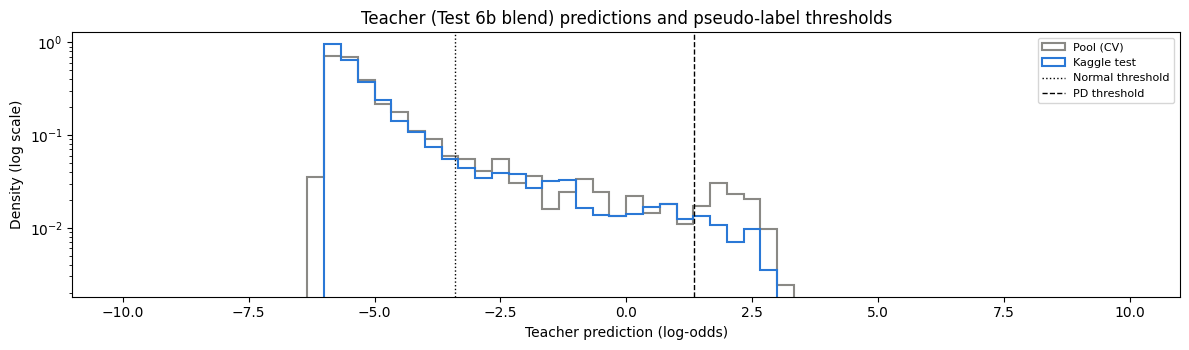

In [7]:
teach_oof, teach_k = models['Blend 6b (teacher)']['oof'][0], models['Blend 6b (teacher)']['kaggle']

o = np.argsort(-teach_oof); n = np.arange(1, len(o) + 1)
prec = np.cumsum(yp[o]) / n
ok = np.flatnonzero((prec >= PL_PRECISION) & (n >= PL_MIN_POS))
assert len(ok), 'no PD threshold reaches the required precision: lower PL_PRECISION'
T_POS = float(teach_oof[o][ok[-1]])
o2 = np.argsort(teach_oof); share = np.cumsum(yp[o2]) / n
ok2 = np.flatnonzero(share <= PL_NEG_PD_SHARE)
assert len(ok2), 'no normal threshold reaches the required purity: raise PL_NEG_PD_SHARE'
T_NEG = float(teach_oof[o2][ok2[-1]])

pos_k = np.flatnonzero(teach_k >= T_POS)
assert len(pos_k), 'no Kaggle measurement passes the PD threshold: pseudo-labelling is not possible with these settings'
neg_all = np.flatnonzero(teach_k <= T_NEG)
n_neg = min(len(neg_all), int(round(len(pos_k) * (1 - yp.mean()) / yp.mean())))
neg_k = np.sort(np.random.default_rng(SEED_BASE).choice(neg_all, n_neg, replace=False))
PL = (np.r_[pos_k, neg_k], np.r_[np.ones(len(pos_k)), np.zeros(len(neg_k))], np.full(len(pos_k) + len(neg_k), PL_WEIGHT))

pl_table = pd.DataFrame({
    'Pseudo-label': ['PD', 'Normal'], 'Teacher threshold': [f'≥ {T_POS:.3f}', f'≤ {T_NEG:.3f}'],
    'CV: share correct': [f'{yp[teach_oof >= T_POS].mean():.1%}', f'{1 - yp[teach_oof <= T_NEG].mean():.2%}'],
    'CV measurements passing': [int((teach_oof >= T_POS).sum()), int((teach_oof <= T_NEG).sum())],
    'Kaggle measurements passing': [len(pos_k), len(neg_all)], 'Used (weight 0.5)': [len(pos_k), len(neg_k)]})
display(pl_table)
print(f'Pseudo-labelled PD share: {len(pos_k) / (len(pos_k) + len(neg_k)):.1%} (pool: {yp.mean():.1%}) | '
      f'quiet recordings among pseudo-normals: {quiet_k[neg_k].mean():.1%} (Kaggle overall: {quiet_k.mean():.1%})')

fig, ax = plt.subplots(figsize=(12, 3.6))
bins = np.linspace(-10, 10, 61)
ax.hist(np.clip(logit(teach_oof), -10, 10), bins=bins, density=True, histtype='step', linewidth=1.5, color=C_GRAY, label='Pool (CV)')
ax.hist(np.clip(logit(teach_k), -10, 10), bins=bins, density=True, histtype='step', linewidth=1.5, color=C_B0, label='Kaggle test')
for t, lab in ((T_NEG, 'Normal threshold'), (T_POS, 'PD threshold')):
    ax.axvline(logit(np.array([t]))[0], color='black', linestyle='--' if t == T_POS else ':', linewidth=1, label=lab)
ax.set_yscale('log'); ax.set_xlabel('Teacher prediction (log-odds)'); ax.set_ylabel('Density (log scale)')
ax.set_title('Teacher (Test 6b blend) predictions and pseudo-label thresholds'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## B2. B0 re-run (check) and B0 with pseudo-labels

B0 is first re-run exactly as in Test 5 (25 repeats × 5 folds, same seeds and folds) to check that this notebook reproduces it: its CV MCC should be 0.726 and its predictions should match the saved ones closely. Then B0 is trained again with the pseudo-labelled Kaggle measurements added to each training part (sample weight 0.5).

In [8]:
F_pool, F_kag, F_test = F_b0.loc[pool_ids].values, F_b0_k.values, F_b0.iloc[test_rows].values

def run_b0_cv(name, pl=None):
    out = dict(oof=np.zeros((N_REPEATS_B0, len(pool))), kaggle=np.zeros(len(F_kag)), test=np.zeros(len(F_test)))
    n_models, t0 = N_REPEATS_B0 * N_FOLDS, time.time()
    for r in range(N_REPEATS_B0):
        fold = fold_ids(SEED_BASE + r)
        for k in range(N_FOLDS):
            va, st = fold == k, fold == (k + 1) % N_FOLDS
            tr = ~(va | st)
            X, y, w = F_pool[tr], yp[tr], np.ones(tr.sum())
            if pl is not None:
                X, y, w = np.vstack([X, F_kag[pl[0]]]), np.r_[y, pl[1]], np.r_[w, pl[2]]
            m = lgb.LGBMClassifier(**LGB_PARAMS, random_state=SEED_BASE + r)
            m.fit(X, y, sample_weight=w, eval_set=[(F_pool[st], yp[st])], callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
            out['oof'][r, va] = m.predict_proba(F_pool[va])[:, 1]
            out['kaggle'] += m.predict_proba(F_kag)[:, 1] / n_models
            out['test'] += m.predict_proba(F_test)[:, 1] / n_models
    print(f'{name}: {n_models} models in {(time.time() - t0) / 60:.1f} min')
    return out

models['B0 (re-run)'] = run_b0_cv('B0 re-run')
saved, rerun = models['B0 (Test 5)'], models['B0 (re-run)']
print(f'B0 re-run check: CV MCC {best_signal_cut(rerun["oof"].mean(0))[0]:.3f} (Test 5: 0.726) | correlation with saved predictions: '
      f'CV {np.corrcoef(rerun["oof"].mean(0), saved["oof"][0])[0, 1]:.4f}, Kaggle {np.corrcoef(rerun["kaggle"], saved["kaggle"])[0, 1]:.4f}')

models['B0_PL'] = run_b0_cv('B0_PL', PL)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

B0 re-run: 125 models in 1.4 min
B0 re-run check: CV MCC 0.726 (Test 5: 0.726) | correlation with saved predictions: CV 1.0000, Kaggle 1.0000


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

B0_PL: 125 models in 1.8 min


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## B3. CNN with pseudo-labels (CNN7b = CNN7a + pseudo-labels) and the 7b blend

In [9]:
models['CNN7b'] = run_cnn_cv('CNN7b', PL)
models['Blend_7b'] = make_blend(models['CNN7b'], models['B0_PL'])
print(f'CNN7b signal-level CV MCC {best_signal_cut(models["CNN7b"]["oof"].mean(0))[0]:.3f} | '
      f'Blend_7b: w = {models["Blend_7b"]["weight"]}, CV MCC {best_signal_cut(models["Blend_7b"]["oof"][0])[0]:.3f}')

CNN7b repeat 1/10 done | 0.8 min
CNN7b repeat 2/10 done | 1.8 min
CNN7b repeat 3/10 done | 2.6 min
CNN7b repeat 4/10 done | 3.5 min
CNN7b repeat 5/10 done | 4.4 min
CNN7b repeat 6/10 done | 5.3 min
CNN7b repeat 7/10 done | 6.5 min
CNN7b repeat 8/10 done | 7.5 min
CNN7b repeat 9/10 done | 8.6 min
CNN7b repeat 10/10 done | 9.6 min
CNN7b signal-level CV MCC 0.696 | Blend_7b: w = 0.25, CV MCC 0.720


# Part C — Results

## C1. Cross-validation (real labels only)

All rows use the same scoring. Measurement MCC per repeat is shown for models trained here (the saved Test 5 and 6b models have reference values from their reports). **Kaggle ÷ pool flag rate** compares how often a model flags PD on the Kaggle test with how often it does in CV (Test 6b: 0.53–0.65).

In [10]:
PER_REPEAT_REF = {'B0 (Test 5)': (0.724, 0.010), f'{TEACHER_CNN} (Test 6b)': (0.693, 0.016)}
rows, cuts = [], {}
for name, r in models.items():
    ens = r['oof'].mean(0)
    sig_mcc, cut = best_signal_cut(ens); cuts[name] = cut
    tn, fp, fn, tp = confusion_matrix(pool_sig['target'].values, to_signal(ens, pool_ids, pool_sig) > cut).ravel()
    if len(r['oof']) > 1 or name in ('CNN7a', 'CNN7b'):
        per = [meas_mcc(r['oof'][i]) for i in range(len(r['oof']))]; pr_m, pr_sd = np.mean(per), np.std(per)
    else:
        pr_m, pr_sd = PER_REPEAT_REF.get(name, (np.nan, np.nan))
    rows.append({'Approach': name, 'Blend weight w': r.get('weight', ''),
                 'Meas. MCC per repeat (mean)': round(pr_m, 3), 'Meas. MCC per repeat (SD)': round(pr_sd, 3),
                 'Ensemble OOF MCC (measurement)': round(meas_mcc(ens), 3), 'Signal-level MCC': round(sig_mcc, 3),
                 'Cut-off': round(cut, 3), 'Recall': f'{tp / (tp + fn):.1%}', 'Precision': f'{tp / (tp + fp):.1%}',
                 'False alarms': f'{fp} of {fp + tn}',
                 'Kaggle ÷ pool flag rate': round((r['kaggle'] > cut).mean() / max((ens > cut).mean(), 1e-9), 2),
                 'Kaggle predicted PD (signals)': int((to_signal(r['kaggle'], ids_k, meta_k) > cut).sum())})
for name, c in cuts.items():
    if c >= THRESHOLDS[-1] or c <= THRESHOLDS[0]:
        print(f'WARNING: {name} cut-off {c} is at the edge of the search grid')
summary7 = pd.DataFrame(rows)
summary7.to_csv(f'{OUT_DIR}/test7_summary.csv', index=False)
summary7

,Approach,Blend weight w,Meas. MCC per repeat (mean),Meas. MCC per repeat (SD),Ensemble OOF MCC (measurement),Signal-level MCC,Cut-off,Recall,Precision,False alarms,Kaggle ÷ pool flag rate,Kaggle predicted PD (signals)
0,B0 (Test 5),,0.724,0.010,0.751,0.726,0.39,71.2%,77.2%,95 of 6952,0.65,741
1,CNN6b_3_aug (Test 6b),,0.693,0.016,0.723,0.704,0.91,75.4%,69.3%,151 of 6952,0.53,711
2,Blend 6b (teacher),0.25,NaN,NaN,0.755,0.729,0.52,69.9%,79.2%,83 of 6952,0.62,684
3,CNN7a,,0.684,0.025,0.719,0.696,0.87,78.8%,65.2%,190 of 6952,0.62,927
4,Blend_7a,0,NaN,NaN,0.751,0.726,0.46,71.2%,77.2%,95 of 6952,0.65,744
5,B0 (re-run),,0.724,0.010,0.751,0.726,0.39,71.2%,77.2%,95 of 6952,0.65,741
6,B0_PL,,0.725,0.012,0.741,0.718,0.33,72.6%,74.4%,113 of 6952,0.71,858
7,CNN7b,,0.699,0.014,0.720,0.696,0.93,73.7%,69.4%,147 of 6952,0.61,807
8,Blend_7b,0.25,NaN,NaN,0.745,0.720,0.43,72.6%,74.9%,110 of 6952,0.66,798


## C2. Did the input fix change the CNN's behaviour on the Kaggle test?

Each CNN is compared with B0 (Test 5) on the Kaggle test at its own cut-off. Test 6b found that `CNN_peaks`' solo flags were mostly **quiet recordings** and mostly wrong in CV. If the fix works, the CNN should raise fewer solo flags, and fewer of them on quiet recordings, without losing CV accuracy.

In [11]:
b0_flag_k = models['B0 (Test 5)']['kaggle'] > cuts['B0 (Test 5)']
b0_flag_cv = models['B0 (Test 5)']['oof'][0] > cuts['B0 (Test 5)']
rows = []
for name in [f'{TEACHER_CNN} (Test 6b)', 'CNN7a', 'CNN7b']:
    flag_k = models[name]['kaggle'] > cuts[name]
    flag_cv = models[name]['oof'].mean(0) > cuts[name]
    solo_k, solo_cv = flag_k & ~b0_flag_k, flag_cv & ~b0_flag_cv
    rows.append({'Model': name, 'Kaggle flagged': int(flag_k.sum()), 'Kaggle: only CNN': int(solo_k.sum()),
                 'Kaggle: only B0': int((b0_flag_k & ~flag_k).sum()),
                 'Only-CNN flags on quiet recordings': f'{quiet_k[solo_k].mean():.0%}' if solo_k.any() else '—',
                 'CV: only-CNN flags that are PD': f'{yp[solo_cv].mean():.1%}' if solo_cv.any() else '—'})
display(pd.DataFrame(rows))

,Model,Kaggle flagged,Kaggle: only CNN,Kaggle: only B0,Only-CNN flags on quiet recordings,CV: only-CNN flags that are PD
0,CNN6b_3_aug (Test 6b),237,29,39,79%,25.0%
1,CNN7a,309,80,18,68%,27.7%
2,CNN7b,269,49,27,71%,29.0%


## C3. Submission files (pre-registered rule)

A file is written for every model trained here. **Submit only the files printed under PRE-REGISTERED SUBMISSIONS**, and record both the private and the public score of each.

In [12]:
for name in ['CNN7a', 'Blend_7a', 'B0_PL', 'CNN7b', 'Blend_7b']:
    p_sig = to_signal(models[name]['kaggle'], ids_k, meta_k)
    sub = pd.DataFrame({'signal_id': meta_k['signal_id'], 'target': (p_sig > cuts[name]).astype(int)})
    sub.to_csv(f'{OUT_DIR}/submission_{name}.csv', index=False)
    print(f'submission_{name}.csv: {sub["target"].sum()} predicted PD ({sub["target"].mean():.1%})')

def pick(blend, cnn, b0_alt):
    w = models[blend]['weight']
    return blend if 0 < w < 1 else (cnn if w == 1 else b0_alt)

to_submit = [f'submission_{x}.csv' for x in [pick('Blend_7a', 'CNN7a', None), pick('Blend_7b', 'CNN7b', 'B0_PL')] if x]
print('\nPRE-REGISTERED SUBMISSIONS:', ', '.join(to_submit))

save = {}
for name, key in [('B0 (re-run)', 'B0_rerun'), ('CNN7a', 'CNN7a'), ('B0_PL', 'B0_PL'), ('CNN7b', 'CNN7b')]:
    save.update({f'oof_{key}': models[name]['oof'].mean(0), f'kaggle_{key}': models[name]['kaggle'], f'test_{key}': models[name]['test']})
np.savez(f'{OUT_DIR}/test7_predictions.npz', pool_ids=pool_ids, kaggle_ids=ids_k, test_ids=ids_all[test_rows],
         pseudo_rows=PL[0], pseudo_labels=PL[1], **save)
with open(f'{OUT_DIR}/test7_settings.json', 'w') as f:
    json.dump({'cutoffs': {k: round(v, 3) for k, v in cuts.items()},
               'blend_weights': {k: models[k]['weight'] for k in ['Blend_7a', 'Blend_7b']},
               'knee_floor': KNEE_FLOOR, 'pseudo_thresholds': {'pd': T_POS, 'normal': T_NEG},
               'pseudo_counts': {'pd': int(len(pos_k)), 'normal_used': int(len(neg_k)), 'normal_available': int(len(neg_all))},
               'median_best_epoch': {k: int(np.median(models[k]['epochs'])) for k in ['CNN7a', 'CNN7b']},
               'submit': to_submit, 'quick_test': QUICK_TEST,
               'total_minutes': round((time.time() - T_START) / 60, 1)}, f, indent=2)
print(f'Total run time: {(time.time() - T_START) / 60:.1f} min')

submission_CNN7a.csv: 927 predicted PD (4.6%)
submission_Blend_7a.csv: 744 predicted PD (3.7%)
submission_B0_PL.csv: 858 predicted PD (4.2%)
submission_CNN7b.csv: 807 predicted PD (4.0%)
submission_Blend_7b.csv: 798 predicted PD (3.9%)

PRE-REGISTERED SUBMISSIONS: submission_Blend_7b.csv
Total run time: 18.5 min
